Christian Basso

Lab 4 - Autograd Training on Fashio Data

CSC 5611

Febuary 11th, 2025

In [1]:
import os
import torch
import torchvision
import time
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from layers import Input, Linear, ReLU, Regularization, MSELoss, Sum, Softmax
from network import Network
import matplotlib.pyplot as plt


In [2]:
EPOCHS = 1
# For simple regression problem
TRAINING_POINTS = 1000

In [3]:
# For fashion-MNIST and similar problems
DATA_ROOT = '/data/csc4611/data/'
FASHION_MNIST_TRAINING = '/data/csc4611/data/fashion_mnist_flattened_training.npz'
FASHION_MNIST_TESTING = '/data/csc4611/data/fashion_mnist_flattened_testing.npz'
CIFAR10_TRAINING = '/data/csc4611/data/cifar10_flattened_training.npz'
CIFAR10_TESTING = '/data/csc4611/data/cifar10_flattened_testing.npz'
CIFAR100_TRAINING = '/data/csc4611/data/cifar100_flattened_training.npz'
CIFAR100_TESTING = '/data/csc4611/data/cifar100_flattened_testing.npz'

In [4]:
# With this block, we don't need to set device=DEVICE for every tensor.
# But you will still need to avoid accidentally getting int types instead of floating-point types.
torch.set_default_dtype(torch.float32)
if torch.cuda.is_available():
     torch.set_default_device(0)
     print("Running on the GPU")
else:
     print("Running on the CPU")

Running on the GPU


In [5]:
def create_linear_training_data():
    """
    This method simply rotates points in a 2D space.
    Be sure to use L2 regression in the place of the final softmax layer before testing on this
    data!
    :return: (x,y) the dataset. x is a torch tensor where columns are training samples and
             y is a torch tensor where columns are one-hot labels for the training sample.
    """
    x = torch.randn((2, TRAINING_POINTS))
    x1 = x[0:1, :].clone()
    x2 = x[1:2, :]
    y = torch.cat((-x2, x1), axis=0)
    return x.T, y.T

In [6]:
def create_folded_training_data():
    """
    This method introduces a single non-linear fold into the sort of data created by create_linear_training_data. Be sure to REMOVE the final softmax layer before testing on this data!
    Be sure to use MSE in the place of the final softmax layer before testing on this
    data!
    :return: (x,y) the dataset. x is a torch tensor where columns are training samples and
             y is a torch tensor where columns are one-hot labels for the training sample.
    """
    x = torch.randn((2, TRAINING_POINTS))
    x1 = x[0:1, :].clone()
    x2 = x[1:2, :]
    x2 *= 2 * ((x2 > 0).float() - 0.5)
    y = torch.cat((-x2, x1), axis=0)
    return x, y

In [7]:
def create_square():
    """
    This is a square example in which the challenge is to determine
    if the points are inside or outside of a point in 2d space.
    insideness is true if the points are inside the square.
    :return: (points, insideness) the dataset. points is a 2xN array of points and insideness is true if the point is inside the square.
    """
    win_x = [2,2,3,3]
    win_y = [1,2,2,1]
    win = torch.tensor([win_x,win_y],dtype=torch.float32)
    win_rot = torch.cat((win[:,1:],win[:,0:1]),axis=1)
    t = win_rot - win # edges tangent along side of poly
    rotation = torch.tensor([[0, 1],[-1,0]],dtype=torch.float32)
    normal = rotation @ t # normal vectors to each side of poly
        # torch.matmul(rotation,t) # Same thing

    points = torch.rand((2,2000),dtype = torch.float32)
    points = 4*points

    vectors = points[:,np.newaxis,:] - win[:,:,np.newaxis] # reshape to fill origin
    insideness = (normal[:,:,np.newaxis] * vectors).sum(axis=0)
    insideness = insideness.T
    insideness = insideness > 0
    insideness = insideness.all(axis=1)
    return points, insideness

In [8]:
def load_dataset_flattened(train=True,dataset='Fashion-MNIST',download=False):
    """
    :param train: True for training, False for testing
    :param dataset: 'Fashion-MNIST', 'CIFAR-10', or 'CIFAR-100'
    :param download: True to download. Keep to false afterwords to avoid unneeded downloads.
    :return: (x,y) the dataset. x is a torch tensor where columns are training samples and
             y is a torch tensor where columns are one-hot labels for the training sample.
    """
    if dataset == 'Fashion-MNIST':
        if train:
            path = FASHION_MNIST_TRAINING
        else:
            path = FASHION_MNIST_TESTING
        num_labels = 10
    elif dataset == 'CIFAR-10':
        if train:
            path = CIFAR10_TRAINING
        else:
            path = CIFAR10_TESTING
        num_labels = 10
    elif dataset == 'CIFAR-100':
        if train:
            path = CIFAR100_TRAINING
        else:
            path = CIFAR100_TESTING
        num_labels = 100
    else:
        raise ValueError('Unknown dataset: '+str(dataset))

    if os.path.isfile(path):
        print('Loading cached flattened data for',dataset,'training' if train else 'testing')
        data = np.load(path)
        x = torch.tensor(data['x'],dtype=torch.float32)
        y = torch.tensor(data['y'],dtype=torch.float32)
        pass
    else:
        class ToTorch(object):
            """Like ToTensor, only redefined by us for 'historical reasons'"""

            def __call__(self, pic):
                return torchvision.transforms.functional.to_tensor(pic)

        if dataset == 'Fashion-MNIST':
            data = torchvision.datasets.FashionMNIST(
                root=DATA_ROOT, train=train, transform=ToTorch(), download=download)
        elif dataset == 'CIFAR-10':
            data = torchvision.datasets.CIFAR10(
                root=DATA_ROOT, train=train, transform=ToTorch(), download=download)
        elif dataset == 'CIFAR-100':
            data = torchvision.datasets.CIFAR100(
                root=DATA_ROOT, train=train, transform=ToTorch(), download=download)
        else:
            raise ValueError('This code should be unreachable because of a previous check.')
        x = torch.zeros((len(data[0][0].flatten()), len(data)),dtype=torch.float32)
        for index, image in enumerate(data):
            x[:, index] = data[index][0].flatten()
        labels = torch.tensor([sample[1] for sample in data])
        y = torch.zeros((num_labels, len(labels)), dtype=torch.float32)
        y[labels, torch.arange(len(labels))] = 1
        np.savez(path, x=x.numpy(), y=y.numpy())
    return x.T, y.T

In [9]:
class Timer(object):
    def __init__(self, name=None, filename=None):
        self.name = name
        self.filename = filename

    def __enter__(self):
        self.tstart = time.time()

    def __exit__(self, type, value, traceback):
        message = 'Elapsed: %.2f seconds' % (time.time() - self.tstart)
        if self.name:
            message = '[%s] ' % self.name + message
        print(message)
        if self.filename:
            with open(self.filename,'a') as file:
                print(str(datetime.datetime.now())+": ",message,file=file)

In [10]:
def compute_loss(Y_pred, Y_true, W1, W2, lambda_l2):
    """Computes softmax and cross-ent loss with l2 reg."""

    # subtract the maximum logit in each row
    max_vals, _ = torch.max(Y_pred, dim=1, keepdim=True)
    stable_logits = Y_pred - max_vals

    # exponentials of the logits
    exp_logits = torch.exp(stable_logits)
    
    # softmax probabilities
    sum_exp = torch.sum(exp_logits, dim=1, keepdim=True)
    softmax_probs = exp_logits / sum_exp 
    
    # log-softmax using the log-sum-exp trick (This was from Chat GPT)
    log_softmax = stable_logits - torch.log(sum_exp)
    
    # Compute cross-entropy loss
    ce_loss = -torch.mean(torch.sum(Y_true * log_softmax, dim=1))
    
    # L2 regularization
    l2_reg = lambda_l2 * (torch.sum(W1 ** 2) + torch.sum(W2 ** 2))
    
    return ce_loss + l2_reg

In [11]:
def compute_acc(y_pred, y_true):
    y_test_labels = torch.argmax(y_true, dim=1)
    predicted_labels = torch.argmax(y_pred, dim=1)
    test_accuracy = (predicted_labels == y_test_labels).float().mean().item() *100
    return test_accuracy

In [12]:
x_train, y_train = create_linear_training_data()
print(x_train.shape)

torch.Size([1000, 2])


## Train model on linear data

In [13]:
if __name__ == '__main__':
    # The code in this section should NOT be in a helper method.
    # But you may choose to occassionally move helper methods before this as
    # the code within them becomes stable.
    #
    # For this week's lab, however, you can likely keep ALL your code
    # right here, with all your variables in the global scope 
    # for simplified debugging.
    with Timer('Total time'):
        lambda_l2 = 0.001
        learning_rate = 0.01
        num_epochs = 40
        batch_size = 5

        input_dim = 2
        hidden_dim = 3
        output_dim = 2

        print("Lambda L2:", lambda_l2)
        print("Learning Rate:", learning_rate)
        print("Number of Epochs:", num_epochs)
        print("Batch Size:", batch_size)
        print("Input Dimension:", input_dim)
        print("Hidden Dimension:", hidden_dim)
        print("Output Dimension:", output_dim)
        print("===============================================================")

        # build network
        # input layer
        data_input = Input(rows=batch_size, cols=input_dim)

        # First linear
        W1 = Input(rows=input_dim, cols=hidden_dim)  
        W1.randomize()
        b1 = Input(rows=1, cols=hidden_dim)    
        b1.randomize()        
        linear1 = Linear(rows=batch_size, X=data_input, W=W1, b=b1, cols=hidden_dim)

        # Activation layer
        relu1 = ReLU(rows=batch_size, prev_output=linear1, cols=hidden_dim)

        # Second linear
        W2 = Input(rows=hidden_dim, cols=output_dim)   
        W2.randomize()
        b2 = Input(rows=1, cols=output_dim)
        b2.randomize()
        linear2 = Linear(rows=batch_size, X=relu1, W=W2, b=b2, cols=output_dim)

        # Create a target placeholder
        target_layer = Input(rows=batch_size, cols=output_dim)

        # Softmax layer
        mse = MSELoss(pred=linear2, targets=target_layer, rows=batch_size)

        # Reg layer
        reg_layer1 = Regularization(W = W1, rows=1, cols=1, lambda_reg=lambda_l2)
        
        reg_layer2 = Regularization(W = W2, rows=1, cols=1, lambda_reg=lambda_l2)
        
        # sum reg layers
        reg_sum = Sum(l_layer = reg_layer1, r_layer = reg_layer2)

        #sum softmax and reg
        J = Sum(l_layer = reg_sum, r_layer = mse)
        
        

        # Build the network
        net = Network()
        net.set_input(data_input)
        net.add(W1)
        net.add(b1)
        net.add(linear1)
        net.add(relu1)
        net.add(W2)
        net.add(b2)
        net.add(linear2)
        net.add(mse)
        net.add(reg_layer1)
        net.add(reg_layer2)
        net.add(reg_sum)
        net.add(J)
        net.set_output(J)

        x_train, y_train = create_linear_training_data()
        
        # Create dataloader for batch processing
        train_dataset = TensorDataset(x_train, y_train)
        generator = torch.Generator(device='cuda')
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    
        # TODO: Train your network.
        with Timer('Training time'):
            for epoch in range(num_epochs):
                for batch_idx, (images, labels) in enumerate(train_loader):

                    # Set the inputs 
                    data_input.set(images)
                    target_layer.set(labels)
                    
                    # Forward pass
                    loss = net.forward(images)
                    
                    # Backward pass 
                    net.backward()
                    
                    # Update parameters
                    net.step(learning_rate)
                    
                    if batch_idx % 100 == 0:
                        print(f"Epoch {epoch} Batch {batch_idx}: Loss = {loss.item()}")
    
        # Report on GPU memory used for this script:
        peak_bytes_allocated = torch.cuda.memory_stats()['active_bytes.all.peak']
        print(f"Peak GPU memory allocated: {peak_bytes_allocated} Bytes")


Lambda L2: 0.001
Learning Rate: 0.01
Number of Epochs: 40
Batch Size: 5
Input Dimension: 2
Hidden Dimension: 3
Output Dimension: 2
Epoch 0 Batch 0: Loss = 0.7789368033409119
Epoch 0 Batch 100: Loss = 0.4501071572303772
Epoch 1 Batch 0: Loss = 0.05508286505937576
Epoch 1 Batch 100: Loss = 0.20508693158626556
Epoch 2 Batch 0: Loss = 0.010393382981419563
Epoch 2 Batch 100: Loss = 0.008953091688454151
Epoch 3 Batch 0: Loss = 0.006021163892000914
Epoch 3 Batch 100: Loss = 0.005224097054451704
Epoch 4 Batch 0: Loss = 0.005506786983460188
Epoch 4 Batch 100: Loss = 0.005667286459356546
Epoch 5 Batch 0: Loss = 0.005900511052459478
Epoch 5 Batch 100: Loss = 0.005441969260573387
Epoch 6 Batch 0: Loss = 0.005617027636617422
Epoch 6 Batch 100: Loss = 0.0886802226305008
Epoch 7 Batch 0: Loss = 0.005549613852053881
Epoch 7 Batch 100: Loss = 0.006648046430200338
Epoch 8 Batch 0: Loss = 0.005807553417980671
Epoch 8 Batch 100: Loss = 0.0057099140249192715
Epoch 9 Batch 0: Loss = 0.005714441183954477
Epo

Epoch 39 Batch 100: Loss = 0.006872374098747969

In [14]:
W1.output @ W2.output

tensor([[-2.9400e-05,  1.0008e+00],
        [-1.0019e+00,  1.9505e-03]], device='cuda:0')

## Train model on FMINST (I did this on accident, so it works but I didnt need to do it for this lab)

In [15]:
def get_metrics(net, data_loader, softmax):
    all_preds = []
    all_true = []
    # Iterate through the test loader
    for batch_idx, (images, labels) in enumerate(data_loader):
        # Forward pass: propagate the images through the network
        test_loss = net.forward(images)
         # Obtain the softmax probabilities
        probs = softmax.classifications
         # Compute predicted class indices from the probabilities
        preds = torch.argmax(probs, dim=1)  # shape: (batch_size,)
          # Convert labels from one-hot to indices (if needed)
         # If labels are already indices, this step can be skipped.
        if labels.ndim > 1 and labels.shape[1] > 1:
            labels_idx = torch.argmax(labels, dim=1)
        else:
            labels_idx = labels

        all_preds.append(preds)
        all_true.append(labels_idx)

     # Concatenate all predictions and true labels along the batch dimension
    all_preds = torch.cat(all_preds)   # should be shape (TotalTestSamples,)
    all_true = torch.cat(all_true)     # should also be shape (TotalTestSamples,)

    # Compute the accuracy
    accuracy = (all_preds == all_true).float().mean()

    print(f"Accuracy: {accuracy.item() * 100:.2f}%")
    print("Loss: ", test_loss.item())
    return (accuracy.item(), test_loss.item())
    

In [16]:
from layers import Input, Linear, ReLU, Regularization, MSELoss, Sum, Softmax
from network import Network
import torch
if __name__ == '__main__':
    # The code in this section should NOT be in a helper method.
    # But you may choose to occassionally move helper methods before this as
    # the code within them becomes stable.
    #
    # For this week's lab, however, you can likely keep ALL your code
    # right here, with all your variables in the global scope 
    # for simplified debugging.
    with Timer('Total time'):
        # TODO: Build your network.
        #dataset = 'CIFAR-10'
        dataset = "Fashion-MNIST"

        # TODO: You may wish to make each TODO below its own pynb cell.
        lambda_l2 = 0.05
        learning_rate = 0.001
        num_epochs = 6
        batch_size = 10

        # Initialize network parameters
        if(dataset == "CIFAR-10"):
            input_dim = 3072
        if dataset == "Fashion-MNIST":
            input_dim = 784
        hidden_dim = 100
        output_dim = 10

        print("Lambda L2:", lambda_l2)
        print("Learning Rate:", learning_rate)
        print("Number of Epochs:", num_epochs)
        print("Batch Size:", batch_size)
        print("Dataset:", dataset)
        print("Input Dimension:", input_dim)
        print("Hidden Dimension:", hidden_dim)
        print("Output Dimension:", output_dim)
        print("===============================================================")

        # build network
        # input layer
        data_input = Input(rows=batch_size, cols=input_dim)

        # First linear
        W1 = Input(rows=input_dim, cols=hidden_dim)  
        W1.randomize()
        b1 = Input(rows=1, cols=hidden_dim)    
        #print(b1.output)
        #b1.randomize()        
        linear1 = Linear(rows=batch_size, X=data_input, W=W1, b=b1, cols=hidden_dim)

        # Activation layer
        relu1 = ReLU(rows=batch_size, prev_output=linear1, cols=hidden_dim)

        # Second linear
        W2 = Input(rows=hidden_dim, cols=output_dim)   
        W2.randomize()
        b2 = Input(rows=1, cols=output_dim)
        #b2.randomize()
        linear2 = Linear(rows=batch_size, X=relu1, W=W2, b=b2, cols=output_dim)

        # Create a target placeholder
        target_layer = Input(rows=batch_size, cols=output_dim)

        # Softmax layer
        softmax_loss = Softmax(x=linear2, y=target_layer, rows=batch_size, cols=10)

        # Reg layer
        reg_layer1 = Regularization(W = W1, rows=1, cols=1, lambda_reg=lambda_l2)
        
        reg_layer2 = Regularization(W = W2, rows=1, cols=1, lambda_reg=lambda_l2)
        
        # sum reg layers
        reg_sum = Sum(l_layer = reg_layer1, r_layer = reg_layer2)

        #sum softmax and reg
        J = Sum(l_layer = reg_sum, r_layer = softmax_loss)
        
        

        # Build the network
        net = Network()
        net.set_input(data_input)
        net.add(W1)
        net.add(b1)
        net.add(linear1)
        net.add(relu1)
        net.add(W2)
        net.add(b2)
        net.add(linear2)
        #net.add(softmax_loss)
        net.add(reg_layer1)
        net.add(reg_layer2)
        net.add(reg_sum)
        net.add(softmax_loss)
        net.add(J)
        net.set_output(J)

        x_train, y_train = load_dataset_flattened(train=True, dataset=dataset, download=True)
        x_test, y_test = load_dataset_flattened(train=False, dataset=dataset)

        test_dataset = TensorDataset(x_test, y_test)
        generator = torch.Generator(device='cuda')
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, generator=generator)

        train_dataset = TensorDataset(x_train, y_train)
        generator = torch.Generator(device='cuda')
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
        

        training_acc = []
        training_loss = []
        testing_acc = []
        testing_loss = []
        
        

        with Timer('Training time'):
            for epoch in range(num_epochs):
                for batch_idx, (images, labels) in enumerate(train_loader):

                    # Set the inputs 
                    #data_input.set(images)
                    target_layer.set(labels)
                    
                    # Forward pass
                    loss = net.forward(images)
                    
                    
                    # Backward pass 
                    net.backward()
                    
                    #print(W1.grad)
                    
                    # Update parameters
                    net.step(learning_rate)
                    
                    
                    if batch_idx % 100 == 0:
                        print(f"Epoch {epoch} Batch {batch_idx}: Loss = {loss.item()}")
                training_loss.append(loss.item())
                train_acc, train_loss = get_metrics(net, train_loader, softmax_loss)
                test_acc, test_loss = get_metrics(net, test_loader, softmax_loss)

                training_acc.append(train_acc)
                #training_loss.append(train_loss)
                testing_acc.append(test_acc)
                testing_loss.append(test_loss)


    
        # Report on GPU memory used for this script:
        peak_bytes_allocated = torch.cuda.memory_stats()['active_bytes.all.peak']
        print(f"Peak GPU memory allocated: {peak_bytes_allocated} Bytes")


Lambda L2: 0.05
Learning Rate: 0.001
Number of Epochs: 6
Batch Size: 10
Dataset: Fashion-MNIST
Input Dimension: 784
Hidden Dimension: 100
Output Dimension: 10
Loading cached flattened data for Fashion-MNIST training
Loading cached flattened data for Fashion-MNIST testing
Epoch 0 Batch 0: Loss = 42.152645111083984
Epoch 0 Batch 100: Loss = 40.60518264770508
Epoch 0 Batch 200: Loss = 40.2464714050293
Epoch 0 Batch 300: Loss = 39.43095779418945
Epoch 0 Batch 400: Loss = 39.29212188720703
Epoch 0 Batch 500: Loss = 38.9879150390625
Epoch 0 Batch 600: Loss = 38.3743782043457
Epoch 0 Batch 700: Loss = 38.13591384887695
Epoch 0 Batch 800: Loss = 37.906124114990234
Epoch 0 Batch 900: Loss = 37.760345458984375
Epoch 0 Batch 1000: Loss = 37.23509216308594
Epoch 0 Batch 1100: Loss = 37.42194366455078
Epoch 0 Batch 1200: Loss = 36.869163513183594
Epoch 0 Batch 1300: Loss = 36.40028381347656
Epoch 0 Batch 1400: Loss = 36.165584564208984
Epoch 0 Batch 1500: Loss = 36.13602066040039
Epoch 0 Batch 1600

KeyboardInterrupt: 

Plot the loss and acc

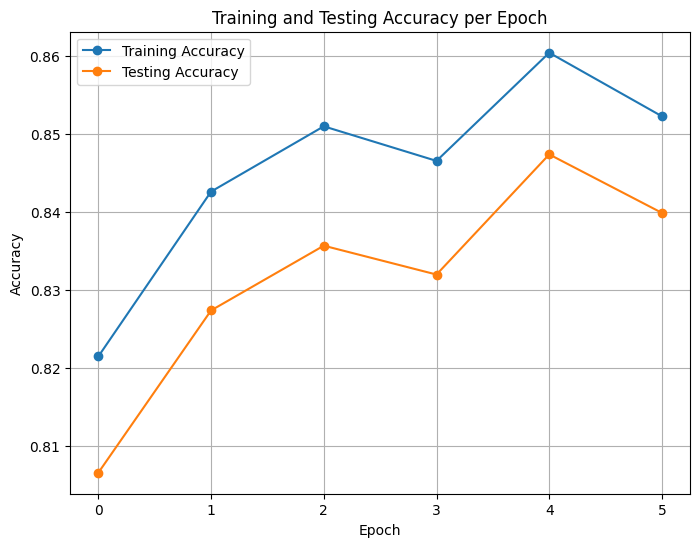

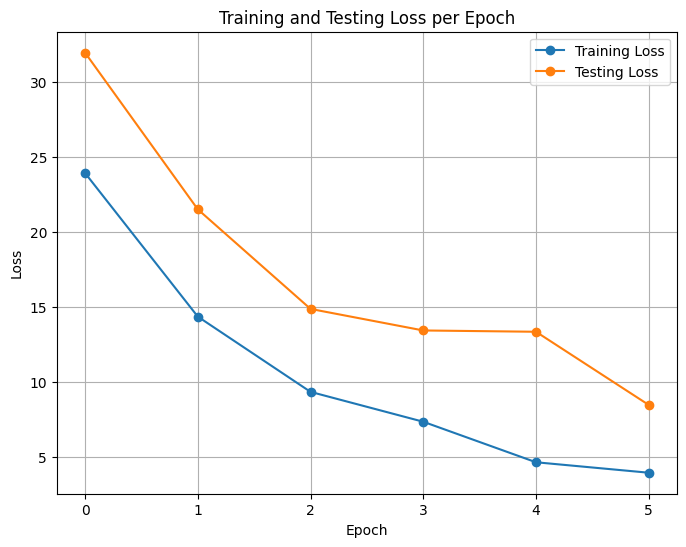

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(training_acc, label="Training Accuracy", marker='o')
plt.plot(testing_acc, label="Testing Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(training_loss, label="Training Loss", marker='o')
plt.plot(testing_loss, label="Testing Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()


Test Accuracy of FMNIST: 85.18%

## Testing on CIFAR - 10

In [25]:
from layers import Input, Linear, ReLU, Regularization, MSELoss, Sum, Softmax
from network import Network
import torch
if __name__ == '__main__':
    # The code in this section should NOT be in a helper method.
    # But you may choose to occassionally move helper methods before this as
    # the code within them becomes stable.
    #
    # For this week's lab, however, you can likely keep ALL your code
    # right here, with all your variables in the global scope 
    # for simplified debugging.
    with Timer('Total time'):
        # TODO: Build your network.
        dataset = 'CIFAR-10'
        #dataset = "Fashion-MNIST"

        # TODO: You may wish to make each TODO below its own pynb cell.
        lambda_l2 = 0.001
        learning_rate = 0.01
        num_epochs = 50
        batch_size = 10

        # Initialize network parameters
        if(dataset == "CIFAR-10"):
            input_dim = 3072
        if dataset == "Fashion-MNIST":
            input_dim = 784
        hidden_dim = 1500
        output_dim = 10

        print("Lambda L2:", lambda_l2)
        print("Learning Rate:", learning_rate)
        print("Number of Epochs:", num_epochs)
        print("Batch Size:", batch_size)
        print("Dataset:", dataset)
        print("Input Dimension:", input_dim)
        print("Hidden Dimension:", hidden_dim)
        print("Output Dimension:", output_dim)
        print("===============================================================")

        # build network
        # input layer
        data_input = Input(rows=batch_size, cols=input_dim)

        # First linear
        W1 = Input(rows=input_dim, cols=hidden_dim)  
        W1.randomize()
        b1 = Input(rows=1, cols=hidden_dim)    
        #print(b1.output)
        #b1.randomize()        
        linear1 = Linear(rows=batch_size, X=data_input, W=W1, b=b1, cols=hidden_dim)

        # Activation layer
        relu1 = ReLU(rows=batch_size, prev_output=linear1, cols=hidden_dim)

        # Second linear
        W2 = Input(rows=hidden_dim, cols=output_dim)   
        W2.randomize()
        b2 = Input(rows=1, cols=output_dim)
        #b2.randomize()
        linear2 = Linear(rows=batch_size, X=relu1, W=W2, b=b2, cols=output_dim)

        # Create a target placeholder
        target_layer = Input(rows=batch_size, cols=output_dim)

        # Softmax layer
        softmax_loss = Softmax(x=linear2, y=target_layer, rows=batch_size, cols=10)

        # Reg layer
        reg_layer1 = Regularization(W = W1, rows=1, cols=1, lambda_reg=lambda_l2)
        
        reg_layer2 = Regularization(W = W2, rows=1, cols=1, lambda_reg=lambda_l2)
        
        # sum reg layers
        reg_sum = Sum(l_layer = reg_layer1, r_layer = reg_layer2)

        #sum softmax and reg
        J = Sum(l_layer = reg_sum, r_layer = softmax_loss)
        
        

        # Build the network
        net = Network()
        net.set_input(data_input)
        net.add(W1)
        net.add(b1)
        net.add(linear1)
        net.add(relu1)
        net.add(W2)
        net.add(b2)
        net.add(linear2)
        #net.add(softmax_loss)
        net.add(reg_layer1)
        net.add(reg_layer2)
        net.add(reg_sum)
        net.add(softmax_loss)
        net.add(J)
        net.set_output(J)

        x_train, y_train = load_dataset_flattened(train=True, dataset=dataset, download=True)
        x_test, y_test = load_dataset_flattened(train=False, dataset=dataset)

        test_dataset = TensorDataset(x_test, y_test)
        generator = torch.Generator(device='cuda')
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, generator=generator)

        train_dataset = TensorDataset(x_train, y_train)
        generator = torch.Generator(device='cuda')
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
        

        training_acc = []
        training_loss = []
        testing_acc = []
        testing_loss = []
        
        

        with Timer('Training time'):
            for epoch in range(num_epochs):
                for batch_idx, (images, labels) in enumerate(train_loader):

                    # Set the inputs 
                    #data_input.set(images)
                    target_layer.set(labels)
                    
                    # Forward pass
                    loss = net.forward(images)
                    
                    
                    # Backward pass 
                    net.backward()
                    
                    #print(W1.grad)
                    
                    # Update parameters
                    net.step(learning_rate)
                    
                    
                    if batch_idx % 100 == 0:
                        print(f"Epoch {epoch} Batch {batch_idx}: Loss = {loss.item()}")

                train_acc, train_loss = get_metrics(net, train_loader, softmax_loss)
                test_acc, test_loss = get_metrics(net, test_loader, softmax_loss)

                training_acc.append(train_acc)
                training_loss.append(train_loss)
                testing_acc.append(test_acc)
                testing_loss.append(test_loss)


    
        # Report on GPU memory used for this script:
        peak_bytes_allocated = torch.cuda.memory_stats()['active_bytes.all.peak']
        print(f"Peak GPU memory allocated: {peak_bytes_allocated} Bytes")


Lambda L2: 0.001
Learning Rate: 0.01
Number of Epochs: 50
Batch Size: 10
Dataset: CIFAR-10
Input Dimension: 3072
Hidden Dimension: 1500
Output Dimension: 10
Loading cached flattened data for CIFAR-10 training
Loading cached flattened data for CIFAR-10 testing
Epoch 0 Batch 0: Loss = 59.333892822265625
Epoch 0 Batch 100: Loss = 48.88008117675781
Epoch 0 Batch 200: Loss = 48.54024887084961
Epoch 0 Batch 300: Loss = 48.304901123046875
Epoch 0 Batch 400: Loss = 48.63662338256836
Epoch 0 Batch 500: Loss = 48.257205963134766
Epoch 0 Batch 600: Loss = 48.331485748291016
Epoch 0 Batch 700: Loss = 47.669803619384766
Epoch 0 Batch 800: Loss = 48.31031799316406
Epoch 0 Batch 900: Loss = 47.813419342041016
Epoch 0 Batch 1000: Loss = 47.71580123901367
Epoch 0 Batch 1100: Loss = 47.74166488647461
Epoch 0 Batch 1200: Loss = 47.96475601196289
Epoch 0 Batch 1300: Loss = 47.63055419921875
Epoch 0 Batch 1400: Loss = 47.5982780456543
Epoch 0 Batch 1500: Loss = 47.64289093017578
Epoch 0 Batch 1600: Loss = 

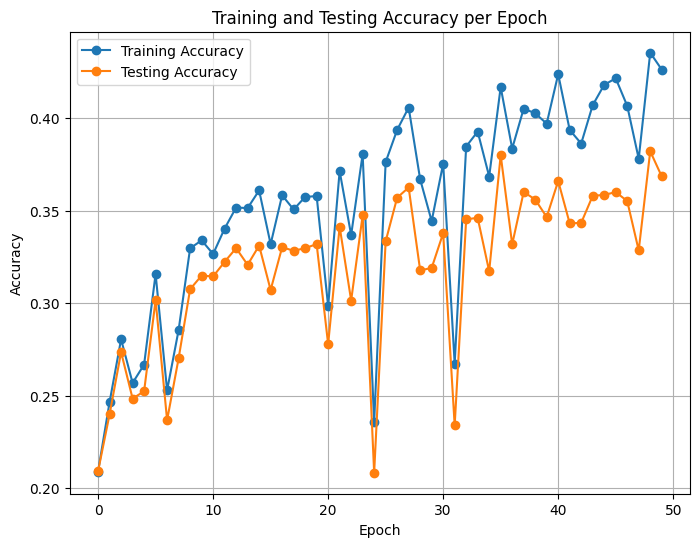

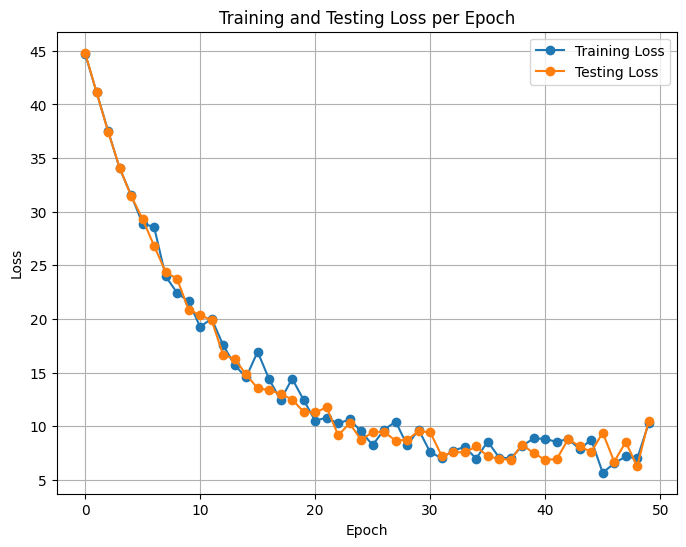

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(training_acc, label="Training Accuracy", marker='o')
plt.plot(testing_acc, label="Testing Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(training_loss, label="Training Loss", marker='o')
plt.plot(testing_loss, label="Testing Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()
